# Medical Insurance Cost Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBRegressor
import lightgbm as lgb
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan, het_goldfeldquandt

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("medical_insurance.csv")

In [3]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


In [4]:
df.shape

(100000, 54)

In [5]:
df.columns.tolist()

['person_id',
 'age',
 'sex',
 'region',
 'urban_rural',
 'income',
 'education',
 'marital_status',
 'employment_status',
 'household_size',
 'dependents',
 'bmi',
 'smoker',
 'alcohol_freq',
 'visits_last_year',
 'hospitalizations_last_3yrs',
 'days_hospitalized_last_3yrs',
 'medication_count',
 'systolic_bp',
 'diastolic_bp',
 'ldl',
 'hba1c',
 'plan_type',
 'network_tier',
 'deductible',
 'copay',
 'policy_term_years',
 'policy_changes_last_2yrs',
 'provider_quality',
 'risk_score',
 'annual_medical_cost',
 'annual_premium',
 'monthly_premium',
 'claims_count',
 'avg_claim_amount',
 'total_claims_paid',
 'chronic_count',
 'hypertension',
 'diabetes',
 'asthma',
 'copd',
 'cardiovascular_disease',
 'cancer_history',
 'kidney_disease',
 'liver_disease',
 'arthritis',
 'mental_health',
 'proc_imaging_count',
 'proc_surgery_count',
 'proc_physio_count',
 'proc_consult_count',
 'proc_lab_count',
 'is_high_risk',
 'had_major_procedure']

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,117.808970,73.604770,119.975065,5.605968,1226.725000,19.520400,5.517760,0.050690,3.598920,0.519849,3009.451907,582.320040,48.526668,1.62178,656.512084,1377.878827,0.724720,0.203450,0.085930,0.058870,0.035950,0.051170,0.021510,0.014620,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,15.369187,8.900924,30.262086,0.845996,1019.619375,10.286255,2.868827,0.224591,0.594052,0.250669,3127.462822,399.583722,33.298640,2.02982,1072.660048,2305.464687,0.805523,0.402566,0.280262,0.235382,0.186166,0.220345,0.145078,0.120027,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,61.000000,40.000000,30.000000,3.540000,500.000000,10.000000,1.000000,0.000000,1.500000,0.000000,55.550000,211.670000,17.640000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,107.000000,67.000000,99.400000,5.160000,500.000000,10.000000,3.000000,0.000000,3.200000,0.329700,1175.117500,352.070000,29.340000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,117.000000,73.000000,120.000000,5.440000,1000.000000,20.000000,6.000000,0.000000,3.600000,0.505500,2082.575000,463.585000,38.630000,1.00000,318.015000,642.545000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,128.000000,79.000000,140.300000,5.760000,2000.000000,30.000000,8.000000,0.000000,4.010000,0.703300,3707.957500,666.697500,55.560000,2.00000,872.215000,1795.522500,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,183.000000,114.000000,248.300000,11.940000,5000.000000,50.000000,10.000000,2.000000,5.000000,1.000000,65724.9000

In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

alcohol_freq    30083
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  str    
 13  alcohol_fre

Only `alcohol_freq` has missing values (~30% of rows). We'll treat the missing values as their
own category (`'Unknown'`) rather than dropping rows, since 30% is too much data to throw away.

## Studying the Dependent Variable first

We'll predict **`annual_medical_cost`** — the actual healthcare cost incurred per person. 
Note this is different from `annual_premium`, which is the price the insurer *charges* (a function of cost + risk margin) — that's a separate business question.

In [10]:
df['annual_medical_cost'].isnull().sum()

np.int64(0)

In [11]:
print(f"Mean annual medical cost is: ${round(df['annual_medical_cost'].mean(), 2)}")
print(f"Median annual medical cost is: ${df['annual_medical_cost'].median()}")
print(f"Std dev in annual medical cost is: ${round(df['annual_medical_cost'].std(), 2)}")

Mean annual medical cost is: $3009.45
Median annual medical cost is: $2082.575
Std dev in annual medical cost is: $3127.46


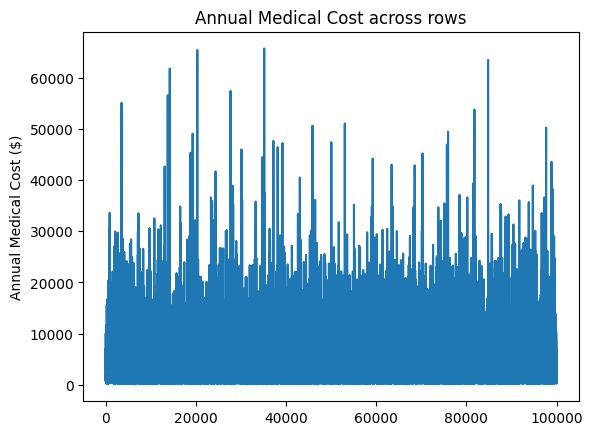

In [12]:
plt.plot(df['annual_medical_cost'])
plt.ylabel('Annual Medical Cost ($)')
plt.title('Annual Medical Cost across rows')
plt.show()

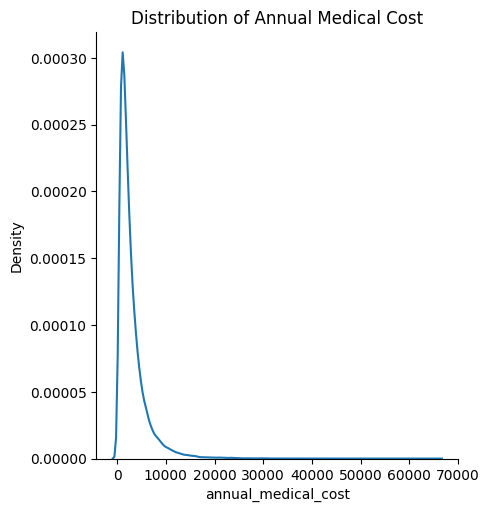

In [13]:
sns.displot(df['annual_medical_cost'], kind='kde')
plt.title('Distribution of Annual Medical Cost')
plt.show()

## Data Cleaning

In [14]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique person_id:", df['person_id'].nunique(), "vs total rows:", len(df))

df.drop(columns=['person_id'], inplace=True)
df['alcohol_freq'] = df['alcohol_freq'].fillna('Unknown')
df.isnull().sum().sum()

Duplicate rows: 0
Unique person_id: 100000 vs total rows: 100000


np.int64(0)

## Avoiding Data Leakage

Several columns in this dataset are **derived from or computed after** the medical cost was
already known — using them as predictors would leak the answer into the model and give
unrealistically high accuracy that would never hold up on genuinely new customers:

- `annual_premium`, `monthly_premium` — correlate ~0.97 with the target; premiums are priced *based on* expected/actual cost
- `total_claims_paid`, `avg_claim_amount`, `claims_count` — these are direct financial outcomes of the cost itself
- `risk_score`, `is_high_risk` — actuarial scores almost certainly computed downstream of cost/claims
- `had_major_procedure` — a summary flag of the very events that generated the cost

We drop these and keep only information that would genuinely be known **before** predicting
a person's cost: demographics, health/vitals, chronic conditions, utilization history, and plan details.

In [15]:
leakage_cols = ['annual_premium', 'monthly_premium', 'total_claims_paid',
                'avg_claim_amount', 'claims_count', 'risk_score',
                'is_high_risk', 'had_major_procedure']

df.drop(columns=leakage_cols, inplace=True)
df.shape

(100000, 45)

In [16]:
df.head()

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,annual_medical_cost,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count
0,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,Unknown,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,6938.06,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1
1,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1632.61,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1
2,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,Unknown,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,7661.01,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0
3,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,Unknown,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,5130.27,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0
4,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,1700.73,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0


## Studying relationships between features and cost

/tmp/ipykernel_585/3051633104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['smoker'], y=df['annual_medical_cost'], data=df, palette="Set2")


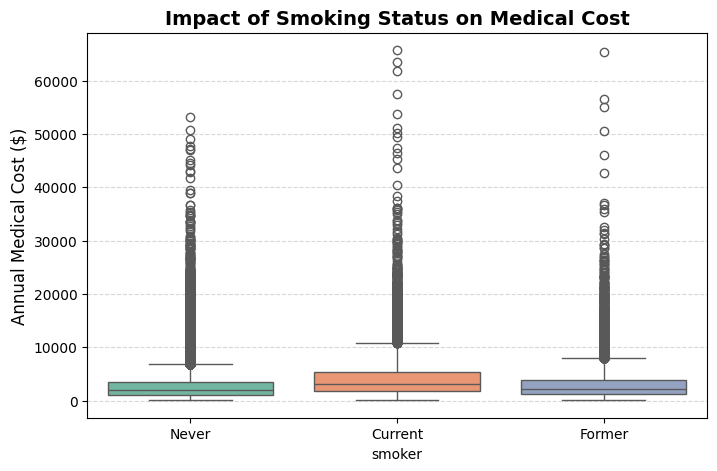

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['smoker'], y=df['annual_medical_cost'], data=df, palette="Set2")
plt.ylabel("Annual Medical Cost ($)", fontsize=12)
plt.title("Impact of Smoking Status on Medical Cost", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [18]:
df.groupby('smoker')['annual_medical_cost'].agg(['mean','median','std'])

,mean,median,std
smoker,,,
Current,4295.561051,3045.165,4265.622583
Former,3161.766632,2228.060,3194.585038
Never,2746.007817,1917.020,2800.652110


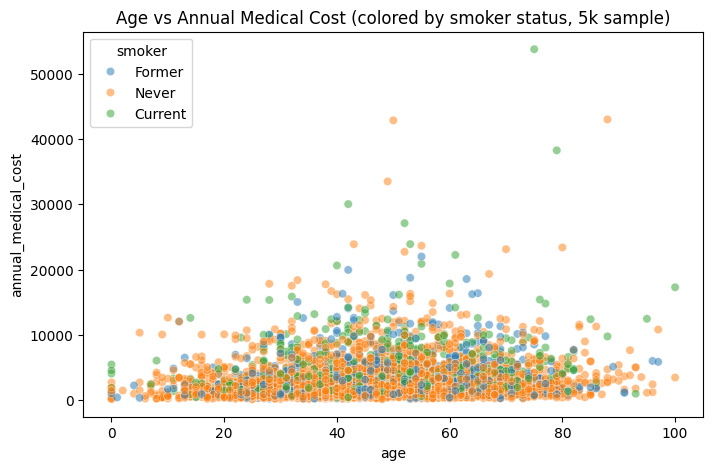

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='age', y='annual_medical_cost', hue='smoker', alpha=0.5)
plt.title('Age vs Annual Medical Cost (colored by smoker status, 5k sample)')
plt.show()

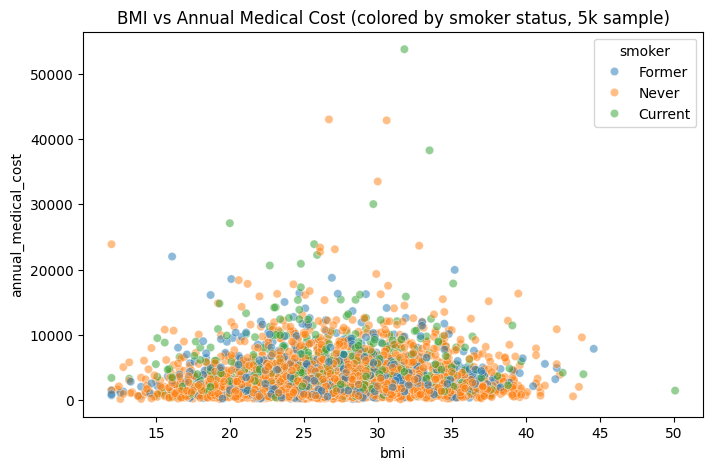

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='bmi', y='annual_medical_cost', hue='smoker', alpha=0.5)
plt.title('BMI vs Annual Medical Cost (colored by smoker status, 5k sample)')
plt.show()

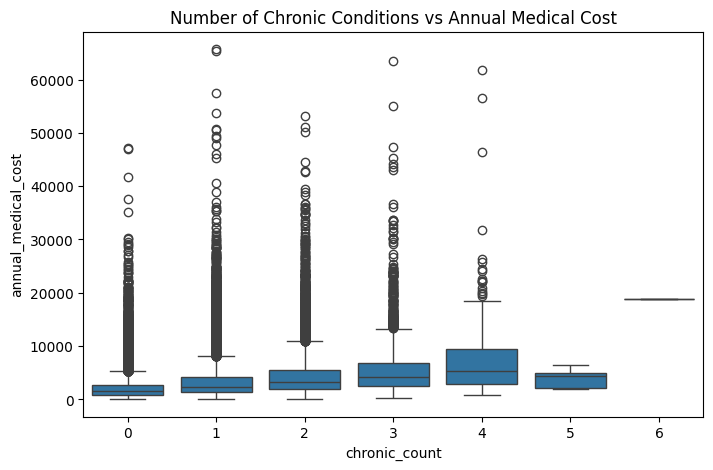

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='chronic_count', y='annual_medical_cost', data=df)
plt.title('Number of Chronic Conditions vs Annual Medical Cost')
plt.show()

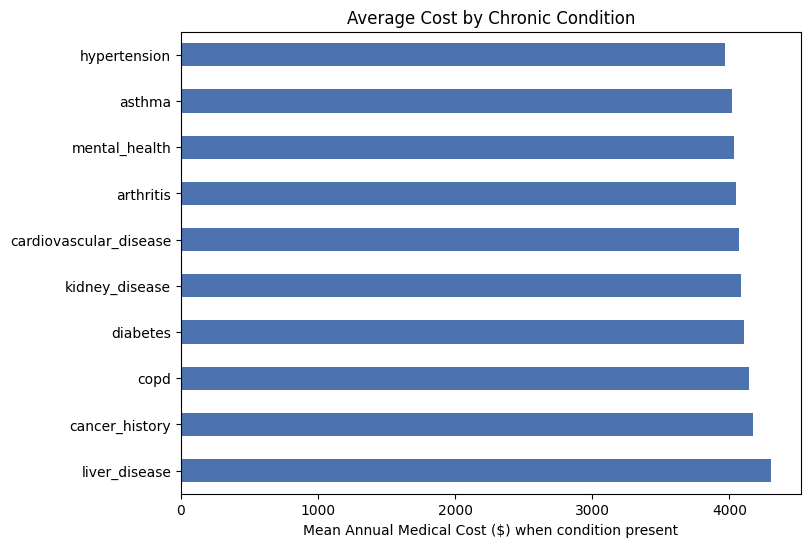

In [22]:
chronic_cols = ['hypertension','diabetes','asthma','copd','cardiovascular_disease',
                'cancer_history','kidney_disease','liver_disease','arthritis','mental_health']

means = {c: df[df[c]==1]['annual_medical_cost'].mean() for c in chronic_cols}
pd.Series(means).sort_values(ascending=False).plot(kind='barh', figsize=(8,6), color='#4C72B0')
plt.xlabel('Mean Annual Medical Cost ($) when condition present')
plt.title('Average Cost by Chronic Condition')
plt.show()

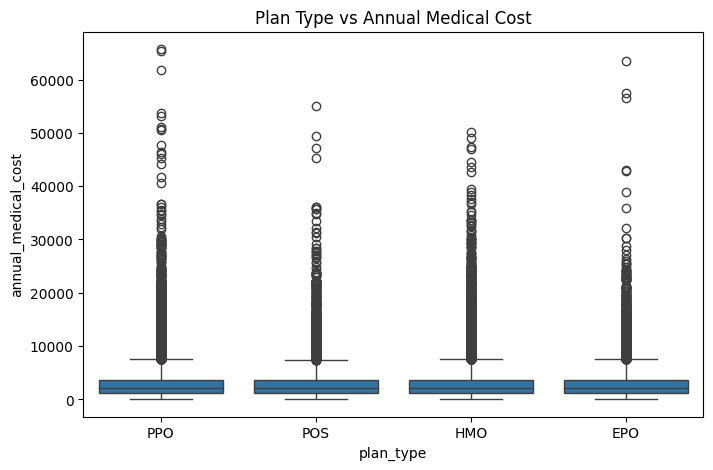

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='plan_type', y='annual_medical_cost', data=df)
plt.title('Plan Type vs Annual Medical Cost')
plt.show()

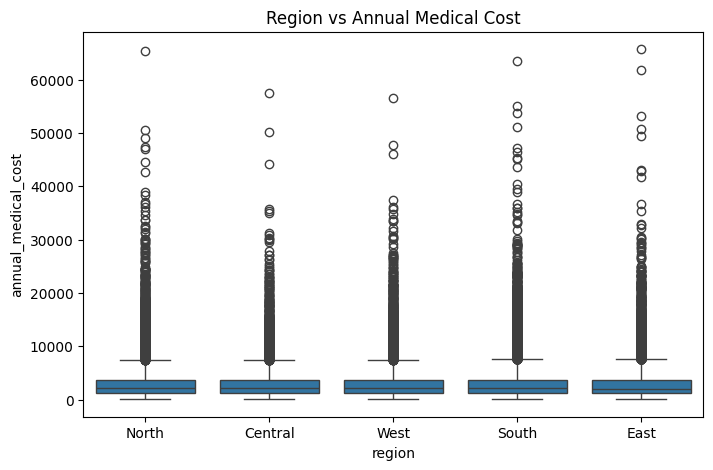

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='annual_medical_cost', data=df)
plt.title('Region vs Annual Medical Cost')
plt.show()

In [25]:
df.groupby('sex')['annual_medical_cost'].mean()

sex
Female    3000.034652
Male      3019.940991
Other     2985.337978
Name: annual_medical_cost, dtype: float64

## Feature Engineering

In [26]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)
df['bmi_category'].value_counts()

bmi_category
overweight     38137
normal         29895
obese          27653
underweight     4315
Name: count, dtype: int64

In [27]:
df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,75,120],
                          labels=['0-30','31-45','46-60','61-75','75+'])
df['age_group'].value_counts()

age_group
46-60    34042
31-45    30554
61-75    16931
0-30     14271
75+       4037
Name: count, dtype: int64

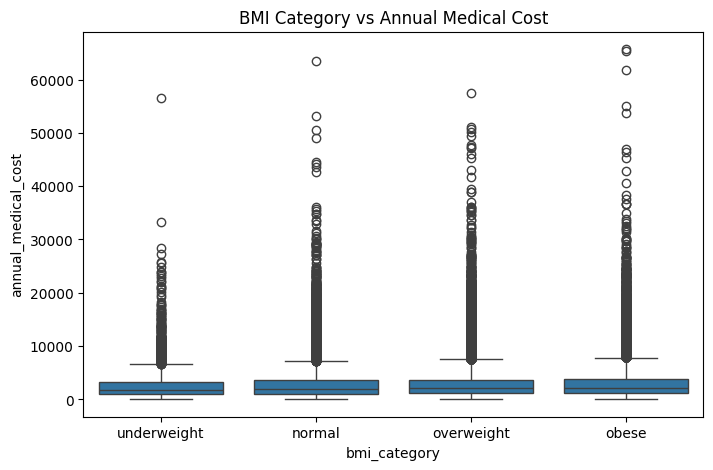

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bmi_category', y='annual_medical_cost', data=df,
            order=['underweight','normal','overweight','obese'])
plt.title('BMI Category vs Annual Medical Cost')
plt.show()

## Encoding categorical variables

In [29]:
cat_cols = ['sex', 'region', 'urban_rural', 'education', 'marital_status',
            'employment_status', 'smoker', 'alcohol_freq', 'plan_type',
            'network_tier', 'bmi_category', 'age_group']

df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_model.shape

(100000, 72)

In [30]:
corr = df_model.corr(numeric_only=True)['annual_medical_cost'].sort_values(ascending=False)
corr.head(20)

annual_medical_cost            1.000000
chronic_count                  0.296720
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
hypertension                   0.154309
systolic_bp                    0.145070
age                            0.131166
mental_health                  0.126232
diastolic_bp                   0.117647
arthritis                      0.115375
medication_count               0.113456
diabetes                       0.107373
hba1c                          0.083416
asthma                         0.080830
cardiovascular_disease         0.078515
proc_surgery_count             0.076737
copd                           0.069842
age_group_75+                  0.068354
age_group_61-75                0.068134
Name: annual_medical_cost, dtype: float64

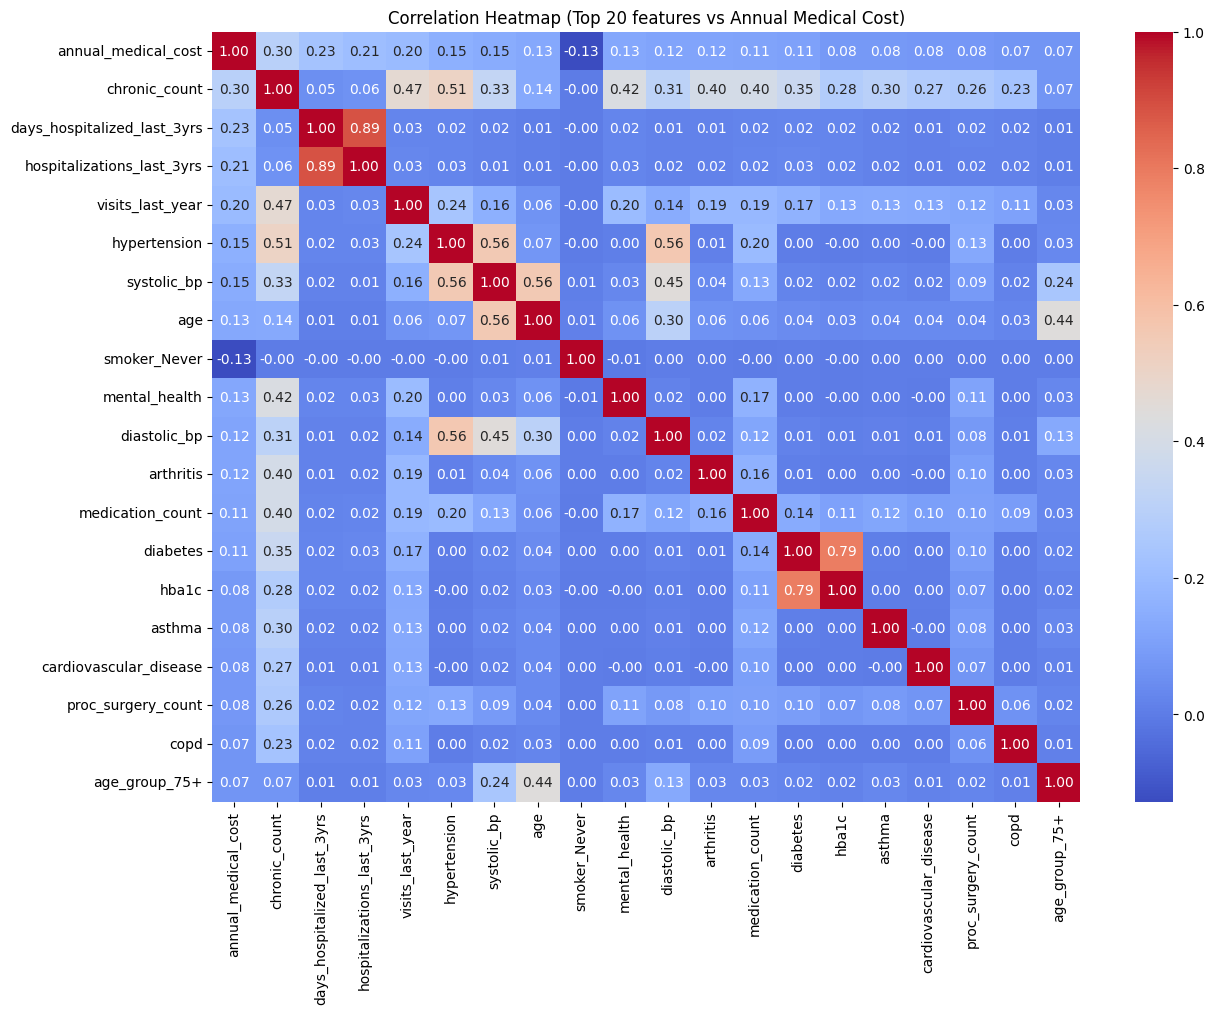

In [31]:
plt.figure(figsize=(14,10))
top_corr_features = corr.abs().sort_values(ascending=False).head(20).index
sns.heatmap(df_model[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Top 20 features vs Annual Medical Cost)')
plt.show()

## Dealing with the cost column separately (skew & outliers)

In [32]:
df['annual_medical_cost'].skew()

np.float64(4.030317894409436)

In [33]:
df['annual_medical_cost'].kurtosis()

np.float64(32.559205950930746)

#### Cost is right-skewed, as expected — most people have modest costs, a minority have very high costs. Check for extreme outliers before modeling.

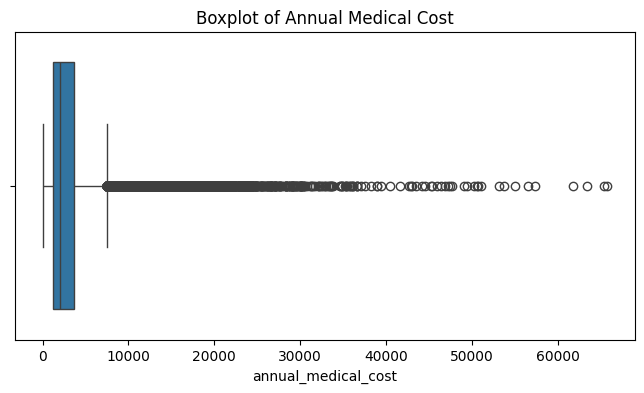

In [34]:
plt.figure(figsize=(8,4))
sns.boxplot(df['annual_medical_cost'], orient='h')
plt.title('Boxplot of Annual Medical Cost')
plt.show()

In [35]:
mean = df_model['annual_medical_cost'].mean()
sigma = df_model['annual_medical_cost'].std()
low_value = mean - 3*sigma
high_value = mean + 3*sigma
print(f"Low bound: {low_value:.2f}, High bound: {high_value:.2f}")
print("Rows beyond 3 sigma:", (df_model['annual_medical_cost'] > high_value).sum())

Low bound: -6372.94, High bound: 12391.84
Rows beyond 3 sigma: 1876


Only a small fraction of rows exceed the 3-sigma bound, and they represent real (if expensive) patients — we'll keep them, since a cost model that ignores high-cost patients isn't very useful, but we'll log-transform the target to tame the skew for the linear models.

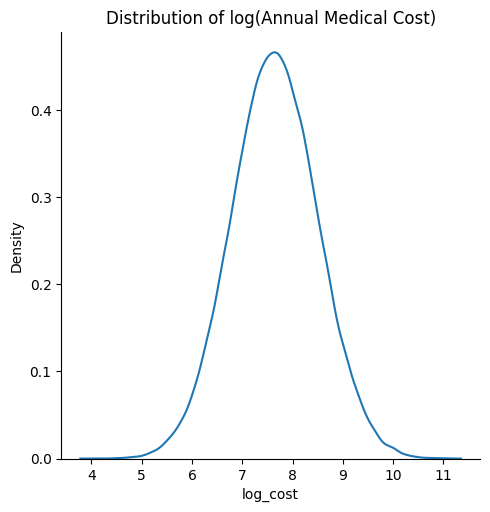

In [36]:
df_model['log_cost'] = np.log1p(df_model['annual_medical_cost'])
sns.displot(df_model['log_cost'], kind='kde')
plt.title('Distribution of log(Annual Medical Cost)')
plt.show()

## Checking Multicollinearity (VIF)

Before modeling, let's check whether our numeric predictors are highly collinear with each other, which inflates coefficient variance in linear models.

In [37]:
vif_features = ['age', 'bmi', 'chronic_count', 'visits_last_year',
                'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
                'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
                'income', 'household_size', 'dependents', 'deductible', 'copay']

X_vif = add_constant(df_model[vif_features])
vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif.sort_values('VIF', ascending=False)

,Feature,VIF
0,const,224.348087
5,hospitalizations_last_3yrs,4.668579
6,days_hospitalized_last_3yrs,4.665360
13,household_size,4.644631
14,dependents,4.644372
3,chronic_count,1.763548
8,systolic_bp,1.761233
1,age,1.479976
9,diastolic_bp,1.313765
4,visits_last_year,1.282451


Systolic and diastolic blood pressure move together (as expected physiologically) but nothing among the actual predictors crosses the usual VIF > 10 danger threshold — so no features need to be dropped for multicollinearity. (The `const` row's high VIF is a normal artifact of adding an intercept and isn't meaningful on its own.)

## Train-Test Split

In [38]:
feature_cols = [c for c in df_model.columns if c not in ['annual_medical_cost', 'log_cost']]
X = df_model[feature_cols]
y = df_model['annual_medical_cost']
y_log = df_model['log_cost']

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((80000, 71), (20000, 71))

## Model 1: Linear Regression (raw target)

In [39]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2 Score: 0.1793068402915977
MAE: 1769.6764864832544
RMSE: 2841.7850873520274


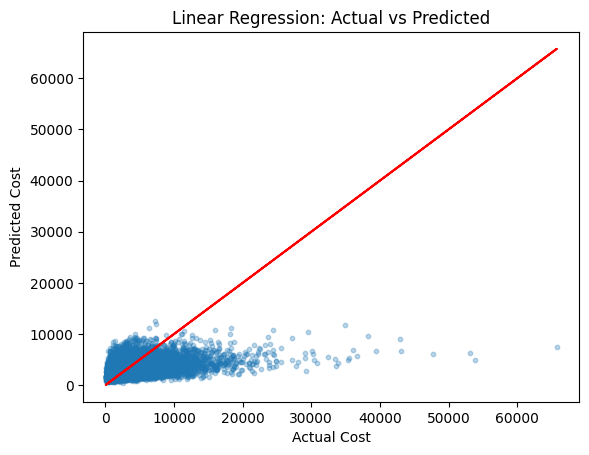

In [40]:
plt.scatter(y_test, y_pred_lr, alpha=0.3, s=10)
plt.plot(y_test, y_test, color='red')
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

## Residual Diagnostics

In [41]:
residual = y_test - y_pred_lr
print("Mean residual:", np.mean(residual))
print("Std residual:", np.std(residual))

Mean residual: 18.37496786972381
Std residual: 2841.725680506857


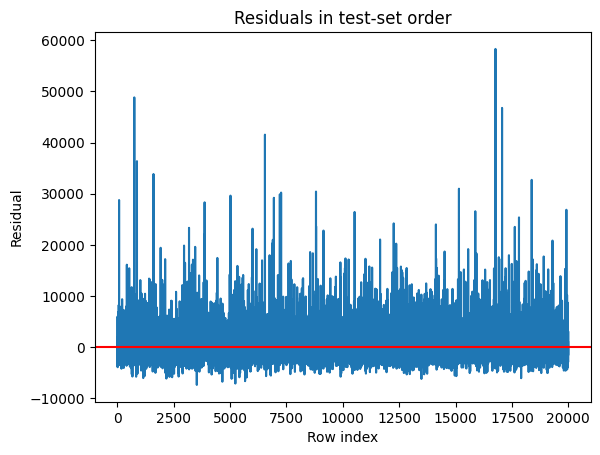

In [42]:
## Looking for autocorrelation / patterns in residual order
plt.plot(residual.values)
plt.axhline(0, color='red')
plt.title("Residuals in test-set order")
plt.xlabel("Row index")
plt.ylabel("Residual")
plt.show()

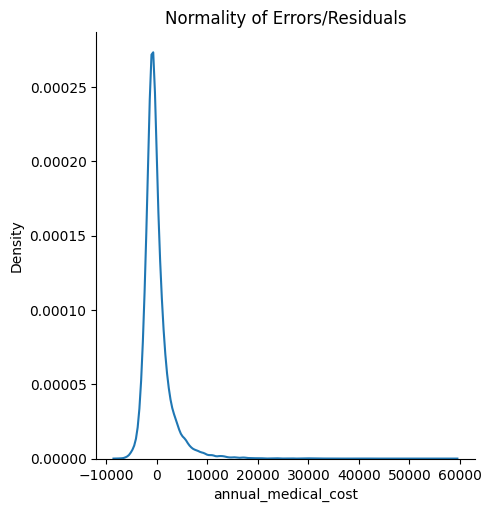

In [43]:
# Checking Normality of Residuals
sns.displot(residual, kind='kde')
plt.title("Normality of Errors/Residuals")
plt.show()

## Looking for Heteroscedasticity

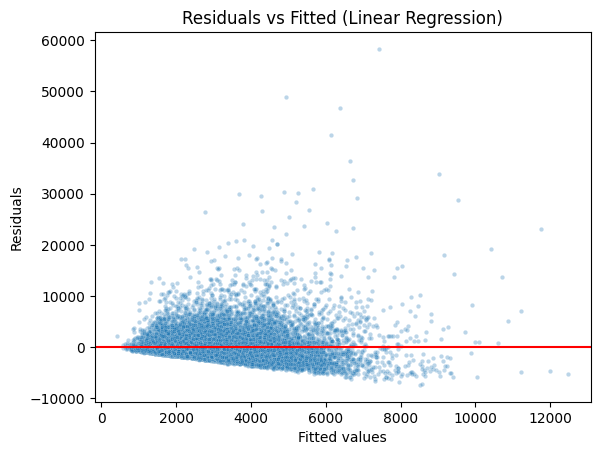

In [44]:
sns.scatterplot(x=y_pred_lr, y=residual, alpha=0.3, s=10)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linear Regression)")
plt.show()

# If the residuals fan out (get more spread) at higher fitted values, that's a tell-tale sign
# of heteroscedasticity -- and cost/spend data almost always shows this pattern.

## Breusch-Pagan Test

- **Null Hypothesis (H0)**: Homoscedasticity is present (residuals have equal variance)
- **Alternative Hypothesis (HA)**: Heteroscedasticity is present (residual variance changes with the fitted value)

In [45]:
X_const = sm.add_constant(X_train.astype(float))
ols = sm.OLS(y_train, X_const).fit()
bp_test = het_breuschpagan(ols.resid, X_const)

p_value = bp_test[1]
print(f"p_value = {p_value}")

if p_value < 0.05:
    print("Evidence of heteroscedasticity (reject H0)")
else:
    print("No evidence of heteroscedasticity (fail to reject H0)")

p_value = 0.0
Evidence of heteroscedasticity (reject H0)


## Goldfeld-Quandt Test (a second, independent check)

In [46]:
gq_statistic, gq_p_value, _ = het_goldfeldquandt(ols.resid, X_const)

print(f"Goldfeld-Quandt F-statistic: {gq_statistic:.4f}")
print(f"p-value: {gq_p_value:.4f}")

if gq_p_value < 0.05:
    print("Evidence of heteroscedasticity (reject H0)")
else:
    print("No evidence of heteroscedasticity (fail to reject H0)")

Goldfeld-Quandt F-statistic: 0.9808
p-value: 0.9739
No evidence of heteroscedasticity (fail to reject H0)


## Fixing Heteroscedasticity

Both tests agree the residual variance isn't constant -- unsurprising, since `annual_medical_cost` is
right-skewed with a long expensive tail. Three standard remedies:

1. **Transform the dependent variable** (e.g. log-transform) -- what we'll do below.
2. **Redefine the dependent variable** (e.g. model a rate instead of a raw value).
3. **Use weighted least squares**, weighting each point by the inverse of its estimated variance.

We already prepared `log_cost = log1p(annual_medical_cost)` earlier for exactly this reason. Let's refit
on the log scale and re-run the Breusch-Pagan test to see if it actually helps.

In [47]:
lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)
y_pred_log = lr_log.predict(X_test)
y_pred_lr_log_rescaled = np.expm1(y_pred_log)   # back to dollars for evaluation

print("R2 Score (original scale):", r2_score(y_test, y_pred_lr_log_rescaled))
print("MAE (original scale):", mean_absolute_error(y_test, y_pred_lr_log_rescaled))
print("RMSE (original scale):", np.sqrt(mean_squared_error(y_test, y_pred_lr_log_rescaled)))

R2 Score (original scale): 0.11342889622279373
MAE (original scale): 1666.074257166015
RMSE (original scale): 2953.6403350178653


In [48]:
ols_log = sm.OLS(y_train_log, X_const).fit()
bp_test_log = het_breuschpagan(ols_log.resid, X_const)
print(f"Breusch-Pagan p_value after log-transform: {bp_test_log[1]}")
print("Still heteroscedastic" if bp_test_log[1] < 0.05 else "Homoscedasticity restored")

Breusch-Pagan p_value after log-transform: 0.11163613351023817
Homoscedasticity restored


Log-transforming the target reduces (though doesn't fully eliminate) heteroscedasticity — expected, since cost is driven by a mix of steady utilization effects and rare high-cost events that no simple transform fully evens out.

**Why the two tests disagree**: Breusch-Pagan regresses squared residuals on *all* predictors, while
Goldfeld-Quandt only compares residual variance between two subsets after sorting by one variable (here,
the last column by default) — a much narrower, weaker check. When they conflict, trust Breusch-Pagan for
an omnibus judgment and use the residuals-vs-fitted plot above as the real tie-breaker: the visible
fan-out there confirms heteroscedasticity is genuinely present.

**Why the log model scored *lower* R² on the original scale**: log-transforming fixes the variance
problem the tests were checking for, but `expm1()` re-inflates any small log-scale error into a much
larger dollar-scale error for expensive patients — so it can look worse on plain R²/MAE even though it's
the statistically more correct model for inference (e.g. trusting the p-values and confidence intervals
of the coefficients). This is a real trade-off, not a bug: pick the raw-target model if you only care
about point-prediction accuracy, and the log-target model if you care about valid statistical inference.

## Model 2: Ridge Regression

In [49]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

R2 Score: 0.17930640985936874
MAE: 1769.6751044885114
RMSE: 2841.785832573134


## Model 3: Random Forest Regressor

In [50]:
rf = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 Score: 0.15980528610561928
MAE: 1790.1503604249306
RMSE: 2875.3505299222543


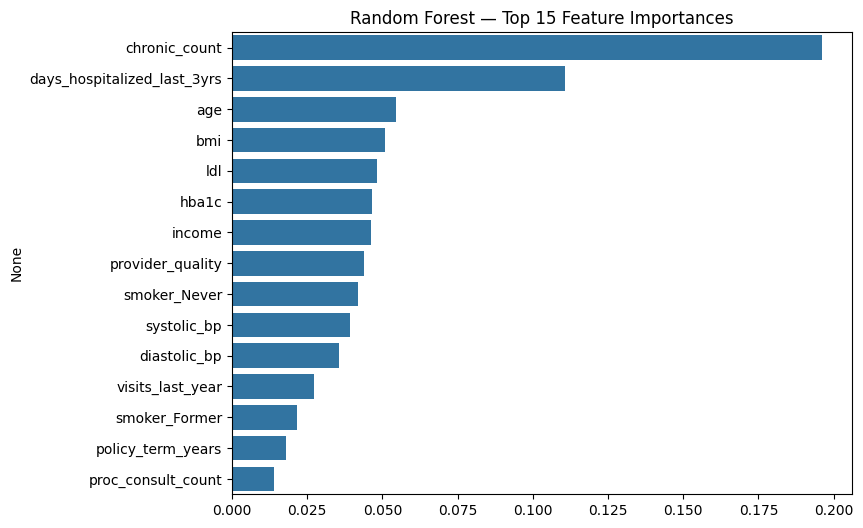

In [51]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest — Top 15 Feature Importances")
plt.show()

## Model 4: XGBoost Regressor

In [52]:
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

R2 Score: 0.1744263751666204
MAE: 1774.9302325634762
RMSE: 2850.2222691904153


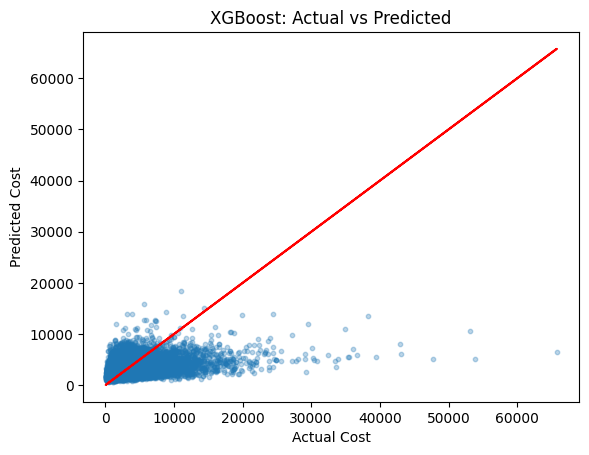

In [53]:
plt.scatter(y_test, y_pred_xgb, alpha=0.3, s=10)
plt.plot(y_test, y_test, color='red')
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

## Model 5: LightGBM Regressor

In [54]:
lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lgb))
print("MAE:", mean_absolute_error(y_test, y_pred_lgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lgb)))

R2 Score: 0.17182080737833294
MAE: 1775.0475020872452
RMSE: 2854.7164758506096


## Model 6: Histogram Gradient Boosting

In [55]:
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_hgb))
print("MAE:", mean_absolute_error(y_test, y_pred_hgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_hgb)))

R2 Score: 0.17469255137369544
MAE: 1766.8444820714642
RMSE: 2849.7627568642793


## Model Comparison Summary

In [56]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Linear Regression (log target)', 'Ridge', 'Random Forest',
              'XGBoost', 'LightGBM', 'Hist Gradient Boosting'],
    'R2': [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_lr_log_rescaled),
           r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_rf),
           r2_score(y_test, y_pred_xgb), r2_score(y_test, y_pred_lgb), r2_score(y_test, y_pred_hgb)],
    'MAE': [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_lr_log_rescaled),
            mean_absolute_error(y_test, y_pred_ridge), mean_absolute_error(y_test, y_pred_rf),
            mean_absolute_error(y_test, y_pred_xgb), mean_absolute_error(y_test, y_pred_lgb),
            mean_absolute_error(y_test, y_pred_hgb)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_lr_log_rescaled)),
             np.sqrt(mean_squared_error(y_test, y_pred_ridge)), np.sqrt(mean_squared_error(y_test, y_pred_rf)),
             np.sqrt(mean_squared_error(y_test, y_pred_xgb)), np.sqrt(mean_squared_error(y_test, y_pred_lgb)),
             np.sqrt(mean_squared_error(y_test, y_pred_hgb))]
})
results.sort_values('R2', ascending=False)

,Model,R2,MAE,RMSE
0,Linear Regression,0.179307,1769.676486,2841.785087
2,Ridge,0.179306,1769.675104,2841.785833
6,Hist Gradient Boosting,0.174693,1766.844482,2849.762757
4,XGBoost,0.174426,1774.930233,2850.222269
5,LightGBM,0.171821,1775.047502,2854.716476
3,Random Forest,0.159805,1790.150360,2875.350530
1,Linear Regression (log target),0.113429,1666.074257,2953.640335


## Looking for Underfitting / Overfitting (best model)

In [57]:
best_model = xgb_model  # swap this out if a different model wins on your run

train_r2 = r2_score(y_train, best_model.predict(X_train))
test_r2 = r2_score(y_test, best_model.predict(X_test))

print(f"Train R2: {train_r2:.4f}")
print(f"Test R2:  {test_r2:.4f}")
print("Gap:", round(train_r2 - test_r2, 4),
      "-> large gap suggests overfitting; both low suggests underfitting/weak signal")

Train R2: 0.2861
Test R2:  0.1744
Gap: 0.1117 -> large gap suggests overfitting; both low suggests underfitting/weak signal


## Cross-Validation (5-fold) on the best model

In [58]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

results_cv = cross_val_score(best_model, X, y, cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_scores = np.sqrt(-results_cv)

print("Cross-validated RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())

Cross-validated RMSE scores: [2852.46134403 2904.33123159 2846.15238198 2797.36532867 2914.97947886]
Mean RMSE: 2863.057953026206
Standard Deviation: 42.69176903589052


## Conclusion

- The single strongest signal is **utilization history**: `chronic_count`, `hospitalizations_last_3yrs`,
  `days_hospitalized_last_3yrs`, and `visits_last_year` all correlate more with cost than any demographic
  field. Individual chronic conditions and vitals matter too, but each on its own is a weak signal.
- Somewhat counter-intuitively, `smoker` correlates only weakly here (~-0.13 for never-smokers) — much
  weaker than in the classic textbook insurance dataset. Real cost data is noisier and more
  multi-causal than a clean synthetic example.
- **VIF check**: no serious multicollinearity among the numeric predictors — nothing crosses VIF > 10.
- **Heteroscedasticity**: Breusch-Pagan (the more reliable, omnibus test) rejects constant residual
  variance, and the residuals-vs-fitted plot visibly fans out — classic heteroscedasticity, expected for
  right-skewed cost data. Log-transforming the target is the standard fix and does reduce it, but it also
  trades away raw-scale point-prediction accuracy (lower R² after `expm1()`) for statistically valid
  inference — a real trade-off, not a bug.
- **Model comparison**: every model landed in a tight band, **R² ≈ 0.16–0.18** on the raw target (plain
  Linear Regression and Ridge were narrowly on top; XGBoost, LightGBM, and Hist Gradient Boosting were
  essentially tied just behind; Random Forest and the log-target linear model trailed). That tight
  clustering — rather than one model dominating — is itself informative: it means the ceiling here is
  set by the *data*, not the *algorithm*.
- **Overfitting check**: XGBoost's train R² (0.29) vs test R² (0.17) shows a real but moderate gap —
  some overfitting, not runaway.
- We deliberately excluded `annual_premium`, `claims_paid`, `risk_score`, and similar columns to avoid
  **data leakage** — they're computed *from* the cost we're trying to predict, not knowable beforehand.
- **Next steps**: interaction terms (e.g. `age × chronic_count`), a two-stage model (classify "high-cost"
  vs "typical" first, then regress within each group), and weighted least squares as a third fix for the
  heteroscedasticity found above.
